# BOÖTES I

Boötes I (BoöI) is a satellite galaxy of the MW, discovered in 2006 through a systematic search for stellar overdensities in the North Galactic Cap using data from the Sloan Digital Sky Survey Data Release 5 (SDSS DR5). 
It is located in the constellation of Boötes, at a distance of approximately 66 kpc from Earth [Belokurov et al. 2006](https://iopscience.iop.org/article/10.1086/507324). 
Morphologically, BoöI is described as one of the faintest galaxies known, with an absolute magnitude of approximately $M_V \approx - 6.02$ mag and a half-light radius of about $220$ pc, typical of  Galactic dwarf spheroidal galaxies. 
Its isodensity contours are elongated and have an irregular shape, suggesting that it may be a disrupted dwarf spheroidal galaxy. 
Its CMD shows a well-defined turn-off, an RGB and an extended HB, indicating an old, metal-poor stellar population. 
The first discovery of RRLs in Boö~I was reported almost simultaneously by [Dall'Ora et al. 2006](https://iopscience.iop.org/article/10.1086/510665) and [Siegel 2006](https://iopscience.iop.org/article/10.1086/508491/meta), who detected in the galaxy a total of 16 RRLs. 

## Libraries

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from astropy.io import ascii, fits
from astropy.visualization import ZScaleInterval, ImageNormalize
from astropy.io.votable import parse, parse_single_table
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table, join

from shapely.geometry import Point, Polygon

import csv

import pandas as pd

from scipy.stats import norm, lognorm, expon, gamma

from statistics import mode

import seaborn as sns

from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset


import warnings
warnings.filterwarnings('ignore')

## Joint Proper Motions Histograms

In [2]:
def scatter_hist(x, y, x_rr, y_rr, ax, ax_histx, ax_histy, center_pm, err_pm):
    
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    
    ax.set_xlim(-20,20)
    ax.set_ylim(-20,20)
    ax.tick_params(labelsize=14)
    ax.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
    ax.set_ylabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
    
    ax.scatter(x, y, marker='o', s=10, label=r'Sources in 6$r_h$', color='lightgrey')
    ax.scatter(x_rr, y_rr, marker='o', edgecolor='k', s=100, label=r'RR Lyrae Variables', color='gold', zorder=2)

    ax_histx.set_ylim(0,1)
    ax_histy.set_xlim(0,1)
    ax_histx.tick_params(labelsize=14)
    ax_histy.tick_params(labelsize=14)
    ax_histx.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax_histy.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax_histx.yaxis.set_major_locator(mticker.MaxNLocator(nbins=3))
    ax_histy.xaxis.set_major_locator(mticker.MaxNLocator(nbins=3))
    
    ax_histx.hist(x, bins=len(x), density=True, color='grey', alpha=0.5, label='Sources in 6$r_h$')
    ax_histy.hist(y, bins=len(y), density=True, color='grey', alpha=0.5, label='Sources in 6$r_h$', orientation='horizontal')
    
    ax_histx.hist(x_rr, bins=len(x_rr), density=True, color='gold', alpha=0.8, label='RR Lyrae Variables')
    ax_histy.hist(y_rr, bins=len(y_rr), density=True, color='gold', alpha=0.8, label='RR Lyrae Variables', orientation='horizontal')
    
    ax_histx.plot([center_pm[0],center_pm[0]], [0,1], c='white', linewidth=5)
    ax_histy.plot([0,1], [center_pm[1],center_pm[1]], c='white', linewidth=5)
    ax_histx.plot([center_pm[0],center_pm[0]], [0,1], c='deepskyblue', linewidth=2, label=r'$\mu_{pmra}$=' + '{:.3f}'.format(center_pm[0]) + '\n' + r'$\sigma_{pmra}$=' + '{:.3f}'.format(err_pm[0]))
    ax_histy.plot([0,1], [center_pm[1],center_pm[1]], c='deepskyblue', linewidth=2, label=r'$\mu_{pmdec}$=' + '{:.3f}'.format(center_pm[1]) + '\n' + r'$\sigma_{pmdec}$=' + '{:.3f}'.format(err_pm[1]))
    
    ax_histx.axvspan(center_pm[0] - 3*err_pm[0], center_pm[0] + 3*err_pm[0], alpha=0.1, color='cyan', zorder=1)
    ax_histy.axhspan(center_pm[1] - 3*err_pm[1], center_pm[1] + 3*err_pm[1], alpha=0.1, color='cyan', zorder=1)
    
    ax_histx.legend(loc=1, fontsize=14, framealpha=0.95)
    ax_histy.legend(loc=1, fontsize=14, framealpha=0.95)

## Wesenheit Relation for RR Lyrae ([Garofalo et al. 2022](https://doi.org/10.1093/mnras/stac735))

In [3]:
## Garofalo et al. 2022, pag. 14

def pw(period, fe, mu0) : # 'period' in log10
    pw_line = - 2.49 * period + 0.14 * fe - 0.88 + mu0

    return pw_line


## Garofalo et al. 2022, pag. 12-13

def wesen(g, bp, rp) :
    w = g - 1.922 * (bp - rp)
    
    return w


## Error Propagation

def wesen_err(g_err, bp_err, rp_err) :
    w_err = g_err + 1.922 * (bp_err + rp_err)
    
    return w_err

## Errors on phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
##### NOTE on errors: 
If using "int_g_average" for $G$-band magnitude, we already have "int_g_average_error"; if using "phot_g_mean_mag", we use the flux-derived error ("phot_g_err"). For $G_{BP}$ and $G_{RP}$, we exclusively use "phot_*_mean_mag" as they are more reliable.

In [4]:
def mag_err(flux, flux_err) :
    mag_error = 1.0857 * flux_err / flux
    
    return mag_error

## Data download

In [5]:
data = pd.read_csv('Data/BootesI_3.csv', header=0)
#cu5

data_rr = pd.read_csv('Data/vari_rrlyrae.csv', header=0, low_memory=False)
#cu7=coordination unit of variables

data_class = pd.read_csv('Data/vari_classifier_result.csv', header=0)

### UFD parameters ([Vivas et al. 2020](https://iopscience.iop.org/article/10.3847/1538-4365/ab67c0), table 1)

In [6]:
vivas_table = pd.read_csv('Papers_tables/Vivas_table1.csv', header=0)

vivas = vivas_table[vivas_table['galaxy'] == 'BootesI']

print(vivas)

    galaxy      ra      dec   M_V  distance  fe_h   r_h  epsilon   PA   r_t  \
0  BootesI  210.02  14.5135 -6.02      66.0 -2.59  10.5     0.26  6.0  37.5   

   N_RR  N_RR.1  N_(RR)  N_RR.2 Ref  Ref.1  Ref.2  
0  15.0       3       2      16   1   16.0  20,21  


### Known RR Lyrae  in [Tau et al. 2024](https://iopscience.iop.org/article/10.3847/1538-3881/ad1509) (table 2)

In [7]:
tau_table = pd.read_csv('Papers_tables/Tau_table2.csv', header=0)

tau = tau_table[tau_table['galaxy'] == 'BootesI']

tau_complete = tau

print('RR Lyrae in Tau et al. (2024): ' + str(len(tau_complete)))


#Tau RR Lyrae + those that do not match the Gaia catalogue

#tau_complete.to_csv('Output/BootesI/BootesI_rr_Tau_complete.csv', index=False)


# - Tau consider one RR Lyrae which does not have a correspondence with any Gaia source_id ("extra_tau" removed)
# - Tau classified a non-variable source as an RR Lyrae, which lacks a source_id in Gaia DR3:
#   we cross-matched RA and Dec using Topcat: source_id = 3727814631180569088

extra_tau = tau.loc[[40]]

tau = tau.drop([40])


# Conversion to integers

tau['source_id'] = tau['source_id'].astype(int)


# From Tau, we keep only the 'source_id' column and merge it with the Gaia Archive data

tau = tau[['source_id']]

#print(tau)


# Merging with vari_classifier

tau = tau.merge(data_class, on='source_id')

#print(tau)


# Merging with vari_rrlyrae

tau_rr = tau.merge(data_rr)
print(tau_rr['source_id'])


print('Correspondence with Gaia Variable Classifier: ' + str(len(tau)))
print('Correspondence with Gaia RR Lyrae: ' + str(len(tau_rr)))


# Tau RR Lyrae + those that do not match the Gaia catalogue
# NOTE: These are all of Tau RR Lyrae excluding the one without a Gaia source_id, 
# so the sample includes both vari_rrlyrae and vari_classifier entries

#tau.to_csv('Output/BootesI/BootesI_rr_Tau.csv', index=False)


# Additional RR Lyrae by Tau

tau_add_class_rr = tau.merge(tau_rr, how='left', indicator=True).query('_merge == "left_only"')
tau_add_class_rr.drop('_merge', axis=len(tau_add_class_rr)-1)

print('Tau considered ' + str(len(tau_add_class_rr)) + ' more RR Lyrae classified by Gaia as Variables:')
print(tau_add_class_rr['source_id'])

#print(tau_add_class_rr)

#tau_add_class_rr.to_csv('Output/BootesI/BootesI_rr_Tau_add.csv', index=False)

RR Lyrae in Tau et al. (2024): 27
0     1243152071642576896
1     1226522469372990208
2     1229801659723433600
3     1230741020611316224
4     1230772597210842624
5     1230825339409289600
6     1230827538432572416
7     1230829771815569536
8     1230833517027065728
9     1230834135502357632
10    1230834925776358912
11    1230835853488763008
12    1230836437604328704
13    1230848326073809280
14    1230850009701023232
15    1230859630427736832
16    1230860695583613824
17    1230914571649196544
18    1231064517547444736
19    1231067163247260160
20    1231507655093621632
21    3728687334175665920
22    3728695065116355456
23    1230612927506112000
Name: source_id, dtype: int64
Correspondence with Gaia Variable Classifier: 26
Correspondence with Gaia RR Lyrae: 24
Tau considered 2 more RR Lyrae classified by Gaia as Variables:
24    1230713292302089728
25    1230819704412148224
Name: source_id, dtype: int64


### Spectroscopic members ([Waller et al. 2022](https://doi.org/10.1093/mnras/stac3563), table 8)

Some RRL "source_ids" in Waller2022 do not have direct Gaia counterparts. However, cross-matching RA and Dec (using TOPCAT) revealed many more matches, so we used this new cross-matched catalogue because Waller used EDR3. Examples:
- Gaia DR3 1230835475531625216 -> DR3 1230835578610843648
- For 1230833486962192640: this is not the actual star

In [8]:
memb_table = pd.read_csv('Papers_tables/Waller8.csv', header=0)

memb_complete = memb_table[memb_table['UFD'] == 'BooI']

print('Spectroscopic Members: ' + str(len(memb_complete)))


## Correspondence with Gaia (gaiadr3.gaia_source)

memb_table_cross = pd.read_csv('Papers_tables/Waller8_BooI_crossmatch.csv', header=0)

memb = memb_table_cross[memb_table_cross['UFD'] == 'BooI']

memb = memb[memb['source_id'] != '—']

memb = memb[memb['PSAT'] > 0.7]

memb['source_id'] = memb['source_id'].astype(int)


## Mask for Sources which are not 'NaN' in proper motions

mask_memb = ((np.isnan(memb['pmra']) == False) & (np.isnan(memb['pmdec']) == False))

memb = memb[mask_memb]

print('Correspondence with Gaia Sources: ' + str(len(memb)))


## Correspondence with Gaia RR Lyrae (vari_rrlyrae)

memb_rr = memb.merge(data_rr)

print('Correspondence with Gaia RR Lyrae: ' + str(len(memb_rr)))

#memb_rr.to_csv('Output/BootesI/BootesI_rr_memb.csv', index=False)

print(memb_rr['source_id'])

Spectroscopic Members: 261
Correspondence with Gaia Sources: 181
Correspondence with Gaia RR Lyrae: 14
0     1230850009701023232
1     1230834925776358912
2     1231064517547444736
3     1230825339409289600
4     1231067163247260160
5     1230827538432572416
6     1230834135502357632
7     1230772597210842624
8     1230848326073809280
9     1230833517027065728
10    1230836437604328704
11    1230829771815569536
12    1230860695583613824
13    1230859630427736832
Name: source_id, dtype: int64


### Geometrical parameters of BootesI from [Vivas et al. 2020](https://iopscience.iop.org/article/10.3847/1538-4365/ab67c0) (table 1)

In [9]:
center = np.array(object=(float(vivas['ra']), float(vivas['dec'])))
r_half = np.array(object=(float(vivas['r_h'])/60.0)) # 10.50 arcmin


## Mask for sources with non-Nan pmra, pmdec, phot_g bp rp, int_g bp rp

mask_initial = ((np.isnan(data['pmra']) == False) & (np.isnan(data['pmdec']) == False) &
               (np.isnan(data['phot_g_mean_mag']) == False) & (np.isnan(data['phot_bp_mean_mag']) == False) &
               (np.isnan(data['phot_rp_mean_mag']) == False))

data = data[mask_initial]

print('Sources within 3° (non-Nan values): ' + str(len(data)))


## Mask for Sources within 6*r_h

mask = ((data['ra'] - center[0])**2 + (data['dec'] - center[1])**2) < (6*r_half)**2

data_6rh = data[mask]

print('Sources within 6r_h: ' + str(len(data_6rh)))

Sources within 3° (non-Nan values): 85258
Sources within 6r_h: 10293


### RR Lyrae + Variable star classified ([Gaia DR3](https://doi.org/10.1051/0004-6361/202243940), [Gaia EDR3](https://doi.org/10.1051/0004-6361/202039657))

In [10]:
rr = data_rr.merge(data)
rr_6rh = data_rr.merge(data_6rh)

print('RR Lyrae within 3°: ' + str(len(rr)))
print('RR Lyrae within 6r_h: ' + str(len(rr_6rh)))

#rr.to_csv('Output/BootesI/BootesI_rr_3deg.csv', index=False)

RR Lyrae within 3°: 75
RR Lyrae within 6r_h: 16


In [11]:
# Two RR Lyrae stars from the Sagittarius stream are classified as spectroscopic members
#   and are also present in Tau et al. (2024): we recover them

merging_rr_memb = rr[rr['source_id'].isin(memb['source_id'])] # this is similar to the already defined memb_rr, but without the values reported in memb

print(len(merging_rr_memb))

14


In [12]:
class_rr = data_class.merge(data)
class_6rh = data_class.merge(data_6rh)

print('Gaia Classified Variables: ' + str(len(class_rr)))
print('Gaia Classified Variables in 6r_h: ' + str(len(class_6rh)))

add_class_rr = class_rr.merge(rr, how='left', indicator=True).query('_merge == "left_only"')

print(str(len(add_class_rr)) + ' additional variables classified by Gaia within 3°:')

print(add_class_rr['source_id'])

#add_class_rr.to_csv('Output/BootesI/BootesI_rr_classifier.csv', index=False)


## The same Classified Variables as Tau et al. 2024

if (len(tau_add_class_rr['source_id']) == len(add_class_rr['source_id'])) :
    print('The same classified by Tau et al. (2024) as RR Lyrae Variables')

Gaia Classified Variables: 77
Gaia Classified Variables in 6r_h: 18
2 additional variables classified by Gaia within 3°:
15    1230713292302089728
63    1230819704412148224
Name: source_id, dtype: int64
The same classified by Tau et al. (2024) as RR Lyrae Variables


### Sagittarius Stream ([Muraveva et al. 2025](https://doi.org/10.1051/0004-6361/202555670), table A3)

In [13]:
datafile_sgr = pd.read_csv('Papers_tables/Muraveva2025_TableA3.csv', header=0)

data_sgr = datafile_sgr[datafile_sgr['source_id'].isin(rr['source_id'])]

print('Sagittarius Stream RR Lyrae Candidates: ' + str(len(data_sgr)))

print(data_sgr['source_id'])


data_sgr_complete = data_sgr

#data_sgr_complete.to_csv('Output/BootesI/BootesI_SgrStream_complete.csv', index=False)


data_sgr = data_sgr.drop(columns = ['ra', 'dec', 'pmra', 'pmdec'])

data_sgr = data_sgr.merge(rr)

#data_sgr.to_csv('Output/BootesI/BootesI_SgrStream.csv', index=False)


## Remove from my RR Lyrae

print('Initial RR Lyrae: ' + str(len(rr)))

rr = rr[~rr['source_id'].isin(data_sgr['source_id'])]

print('RR Lyrae without those in Sagittarius Stream: ' + str(len(rr)))

Sagittarius Stream RR Lyrae Candidates: 16
913     1243152071642576896
914     1243448420090325376
915     1243606273024006016
2380    1226636681143761152
2385    1229801659723433600
2386    1230612927506112000
2387    1230741020611316224
2388    1230829771815569536
2389    1231507655093621632
2393    1233221553202749568
4453    3727425197905600768
4454    3727758079346460928
4457    3728687334175665920
4531    3740971284239135360
4532    3741047597218556416
4982    1230836437604328704
Name: source_id, dtype: int64
Initial RR Lyrae: 75
RR Lyrae without those in Sagittarius Stream: 59


In [14]:
# Two RR Lyrae stars from the Sagittarius stream are classified as spectroscopic members
#   and are also present in Tau et al. (2024): we recover them;
#   we leave 'data_sgr' as the RRLs of Muraveva2025, but we subsequently treat them as the RRLs of Boötes I.

merging_memb_sgr = memb.merge(data_sgr)

print('Sagittarius Stream RRLs also Spectroscopic Members:')
print(merging_memb_sgr['source_id'])


rr = rr.merge(merging_rr_memb, how='outer')

rr_6rh = rr.merge(data_6rh)

print('RR Lyrae with all spectroscopic members: ' + str(len(rr)))
print('RR Lyrae within 6r_h: ' + str(len(rr_6rh)))

#print(rr)

Sagittarius Stream RRLs also Spectroscopic Members:
0    1230836437604328704
1    1230829771815569536
Name: source_id, dtype: int64
RR Lyrae with all spectroscopic members: 61
RR Lyrae within 6r_h: 15


### Errors on phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag

In [15]:
rr['phot_g_mean_mag_error'] = mag_err(rr['phot_g_mean_flux'], rr['phot_g_mean_flux_error'])
rr['phot_bp_mean_mag_error'] = mag_err(rr['phot_bp_mean_flux'], rr['phot_bp_mean_flux_error'])
rr['phot_rp_mean_mag_error'] = mag_err(rr['phot_rp_mean_flux'], rr['phot_rp_mean_flux_error'])

add_class_rr['phot_g_mean_mag_error'] = mag_err(add_class_rr['phot_g_mean_flux'], add_class_rr['phot_g_mean_flux_error'])
add_class_rr['phot_bp_mean_mag_error'] = mag_err(add_class_rr['phot_bp_mean_flux'], add_class_rr['phot_bp_mean_flux_error'])
add_class_rr['phot_rp_mean_mag_error'] = mag_err(add_class_rr['phot_rp_mean_flux'], add_class_rr['phot_rp_mean_flux_error'])

data_sgr['phot_g_mean_mag_error'] = mag_err(data_sgr['phot_g_mean_flux'], data_sgr['phot_g_mean_flux_error'])
data_sgr['phot_bp_mean_mag_error'] = mag_err(data_sgr['phot_bp_mean_flux'], data_sgr['phot_bp_mean_flux_error'])
data_sgr['phot_rp_mean_mag_error'] = mag_err(data_sgr['phot_rp_mean_flux'], data_sgr['phot_rp_mean_flux_error'])

## Maps

### RA - Dec

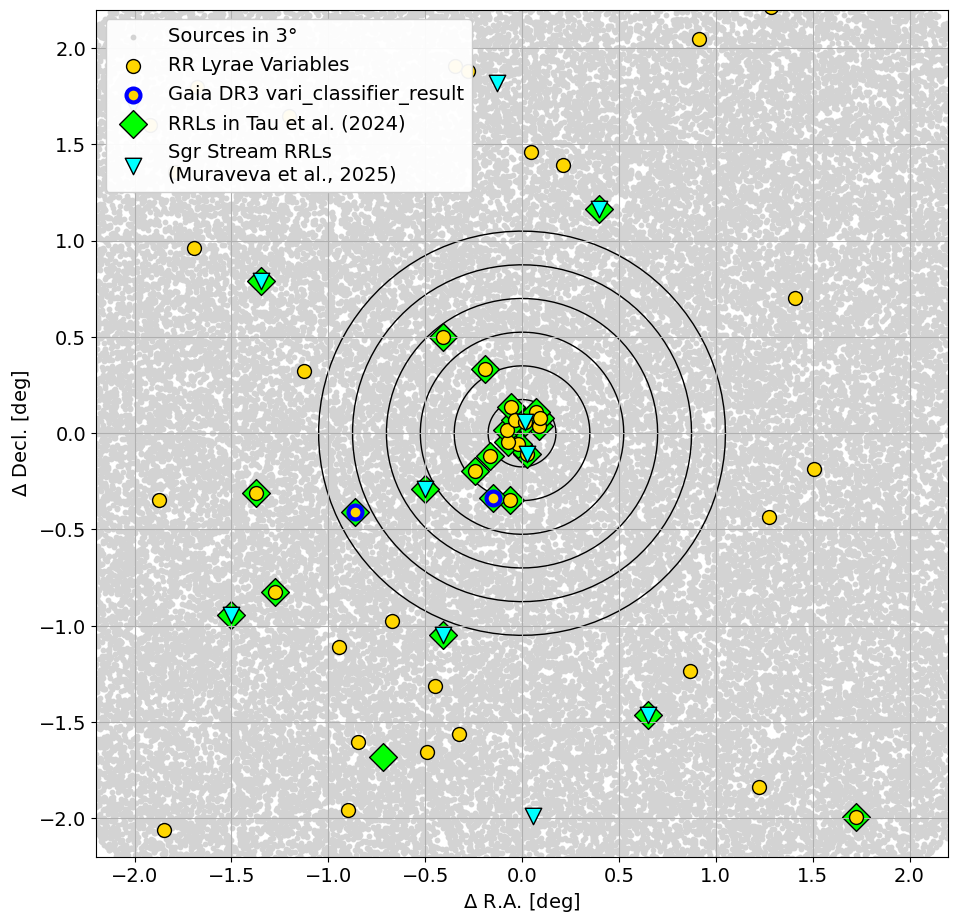

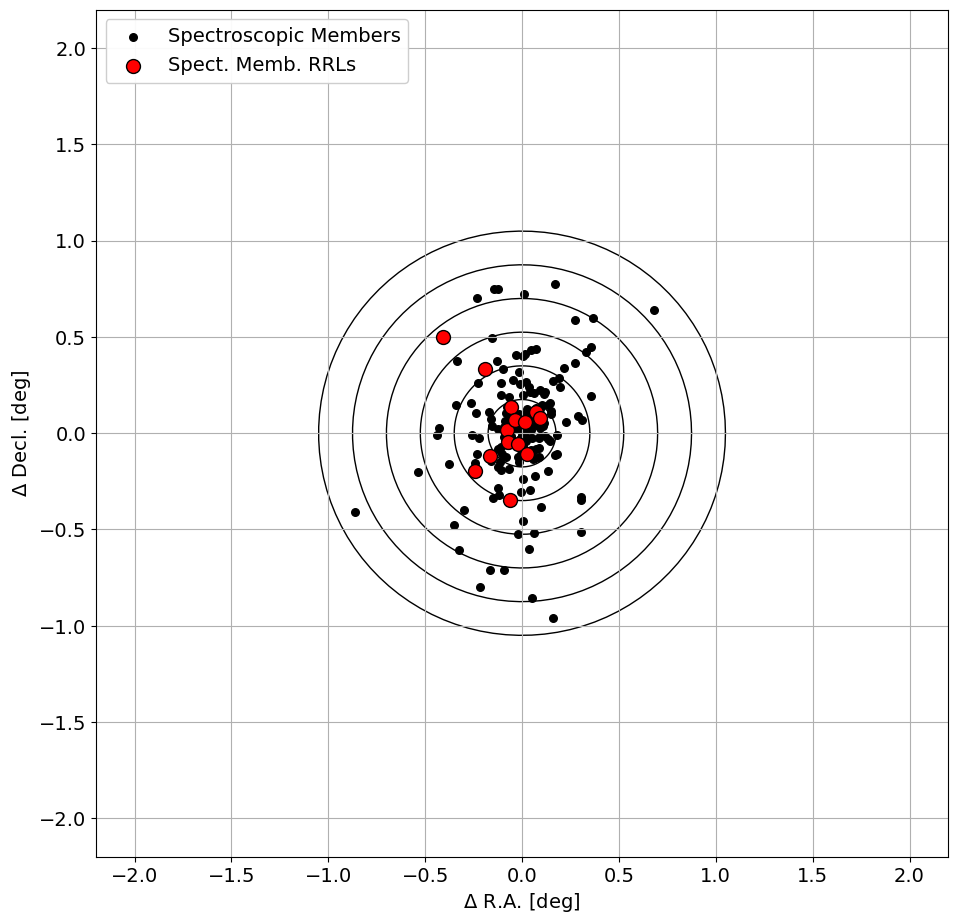

In [16]:
# Zoom in

t = np.linspace(0, 2*np.pi, 100)

plt.figure(figsize=(11,11))
plt.xlim(-2.2,2.2)
plt.ylim(-2.2,2.2)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(data['ra'] - center[0], data['dec'] - center[1], s=10, marker='o', c='lightgrey', label='Sources in 3°', zorder=0)
plt.scatter(rr['ra'] - center[0], rr['dec'] - center[1], s=100, marker='o', color='gold', edgecolor='k', label='RR Lyrae Variables', zorder=2)
plt.scatter(add_class_rr['ra'] - center[0], add_class_rr['dec'] - center[1], s=100, marker='o', color='gold', edgecolor='blue', linewidth=3, label='Gaia DR3 vari_classifier_result', zorder=2)
plt.scatter(tau['ra'] - center[0], tau['dec'] - center[1], s=200, marker='D', c='lime', edgecolor='k', label='RRLs in Tau et al. (2024)', zorder=1)
plt.scatter(extra_tau['ra'] - center[0], extra_tau['dec'] - center[1], s=200, c='lime', marker='D', edgecolor='k', zorder=1)
plt.scatter(data_sgr['ra'] - center[0], data_sgr['dec'] - center[1], s=140, marker='v', color='cyan', edgecolor='k', label='Sgr Stream RRLs\n(Muraveva et al., 2025)', zorder=2)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*4*np.cos(t),r_half*4*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*5*np.cos(t),r_half*5*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*6*np.cos(t),r_half*6*np.sin(t),c='k', linewidth=1, zorder=0)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/BootesI/BootesI_paper01.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


# Spectroscopic Members

plt.figure(figsize=(11,11))
plt.xlim(-2.2,2.2)
plt.ylim(-2.2,2.2)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(memb['ra'] - center[0], memb['dec'] - center[1], s=30, marker='o', c='black', edgecolor='k', label='Spectroscopic Members', zorder=1)
plt.scatter(memb_rr['ra'] - center[0], memb_rr['dec'] - center[1], s=100, marker='o', c='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=3)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*4*np.cos(t),r_half*4*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*5*np.cos(t),r_half*5*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*6*np.cos(t),r_half*6*np.sin(t),c='k', linewidth=1, zorder=0)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/BootesI/BootesI_paper02.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

### Colormap of RR Lyrae based on 'int_average_g'

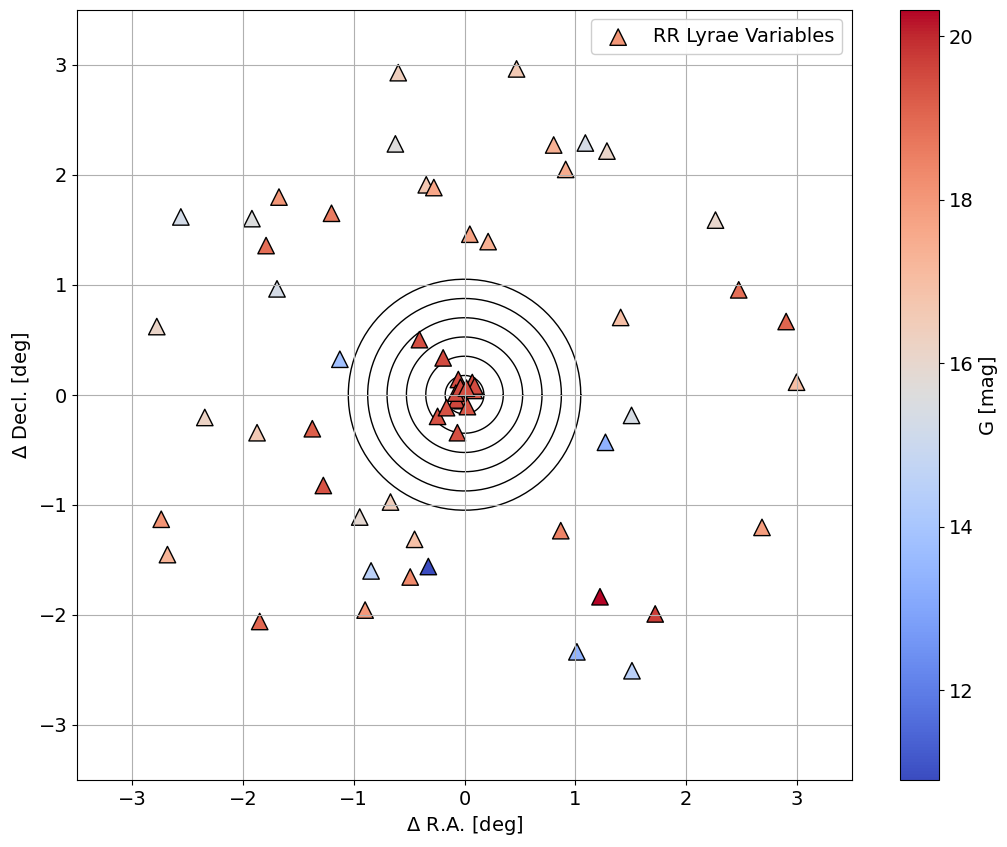

In [17]:
plt.figure(figsize=(12.5,10))
plt.xlim(-3.5,3.5)
plt.ylim(-3.5,3.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(rr['ra'] - center[0], rr['dec'] - center[1], c=rr['int_average_g'], cmap='coolwarm', s=140, marker='^', edgecolor='k', label='RR Lyrae Variables', zorder=1)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*4*np.cos(t),r_half*4*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*5*np.cos(t),r_half*5*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*6*np.cos(t),r_half*6*np.sin(t),c='k', linewidth=1, zorder=0)

plt.legend(loc=1, fontsize=14, framealpha=0.95)
plt.grid(True)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
cbar.set_label('G [mag]', fontsize=14)
plt.savefig('Plot/BootesI/BootesI_colormap.png', bbox_inches='tight', pad_inches=0)
plt.show()

#### Remove spectroscopic RR Lyrae stars from 'data_sgr' (Sgr Stream)

In [18]:
print(len(data_sgr))

data_sgr = data_sgr[~data_sgr['source_id'].isin(merging_memb_sgr['source_id'])]

print(len(data_sgr))

16
14


## RR Lyrae selection through Proper Motions + PWZ

### Proper Motions

#### Errors on Proper Motions ([Gaia EDR3](https://doi.org/10.1051/0004-6361/202039657), table 3): comparison with Spectroscopic Members

In [19]:
# Cut at pm_error = 0.5

print('Initial RR Lyrae: ', len(rr))

mask_pm05 = ((rr['pmra_error'] < 0.5) | (rr['pmdec_error'] < 0.5))
pm05 = rr[mask_pm05]

print('RR Lyrae with pmra_error and pmdec_error < 0.5: ', len(pm05))

if len(pm05) < len(rr) :
    print(str(len(rr) - len(pm05)) + ' RR Lyrae removed:')
    print(rr[~mask_pm05]['source_id'])
    
#rr[~mask_pm05].to_csv('Output/BootesI/BootesI_pmerr05.csv', index=False)

Initial RR Lyrae:  61
RR Lyrae with pmra_error and pmdec_error < 0.5:  60
1 RR Lyrae removed:
44    1229545370435213056
Name: source_id, dtype: int64


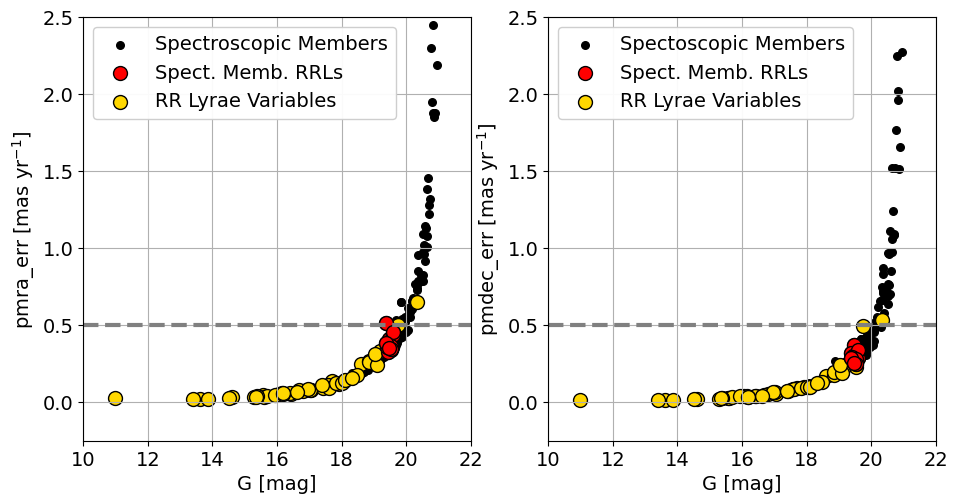

In [20]:
## PM ERRORS

pm1, (pmraerr1, pmdecerr1) = plt.subplots(1, 2, figsize=(11,5.5))

# PM RA with Spectroscopic Members

pmraerr1.set_xlim(10,22)
pmraerr1.set_ylim(-0.25,2.5)
pmraerr1.tick_params(labelsize=14)
pmraerr1.set_xlabel('G [mag]', fontsize=14)
pmraerr1.set_ylabel(r'pmra_err [mas yr$^{-1}$]', fontsize=14)
pmraerr1.scatter(memb['phot_g_mean_mag'], memb['pmra_error'], s=30, marker='o', color='black', edgecolor='k', label='Spectroscopic Members')
pmraerr1.scatter(memb_rr['phot_g_mean_mag'], memb_rr['pmra_error'], s=100, marker='o', color='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=2)
pmraerr1.scatter(rr['phot_g_mean_mag'], rr['pmra_error'], s=100, marker='o', color='gold', edgecolor='k', label='RR Lyrae Variables')
pmraerr1.plot([10,22], [0.5,0.5], color='grey', linewidth=3, linestyle='dashed')
pmraerr1.legend(loc=0, fontsize=14, framealpha=0.95)
pmraerr1.grid(True)

## PM DEC with Spectroscopic Members

pmdecerr1.set_xlim(10,22)
pmdecerr1.set_ylim(-0.25,2.5)
pmdecerr1.tick_params(labelsize=14)
pmdecerr1.set_xlabel('G [mag]', fontsize=14)
pmdecerr1.set_ylabel(r'pmdec_err [mas yr$^{-1}$]', fontsize=14)
pmdecerr1.scatter(memb['phot_g_mean_mag'], memb['pmdec_error'], s=30, marker='o', color='black', edgecolor='k', label='Spectoscopic Members')
pmdecerr1.scatter(memb_rr['phot_g_mean_mag'], memb_rr['pmdec_error'], s=100, marker='o', color='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=2)
pmdecerr1.scatter(rr['phot_g_mean_mag'], rr['pmdec_error'], s=100, marker='o', color='gold', edgecolor='k', label='RR Lyrae Variables')
pmdecerr1.plot([10,22], [0.5,0.5], color='grey', linewidth=3, linestyle='dashed')
pmdecerr1.legend(loc=0, fontsize=14, framealpha=0.95)
pmdecerr1.grid(True)

plt.savefig('Plot/BootesI/BootesI_paper03.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


In [21]:
# pm_error < 0.5 cut

rr = rr[mask_pm05]

#### Histograms

In [22]:
## Gaussian of Data

mask3 = ((data_6rh['pmra'] > -20) & (data_6rh['pmra'] < 20) & (data_6rh['pmdec'] > -20) & (data_6rh['pmdec'] < 20))
data_mask3 = data_6rh[mask3]

mu_ra, std_ra = norm.fit(data_mask3['pmra'])
mu_dec, std_dec = norm.fit(data_mask3['pmdec'])

x = np.linspace(-50, 50, 1000)
p_ra = norm.pdf(x, mu_ra, std_ra)
p_dec = norm.pdf(x, mu_dec, std_dec)


## Gaussian of RR Lyrae in 3°

mu_rr_ra, std_rr_ra = norm.fit(rr['pmra'])
mu_rr_dec, std_rr_dec = norm.fit(rr['pmdec'])

x_rr = np.linspace(-50, 50, 1000)
p_rr_ra = norm.pdf(x_rr, mu_rr_ra, std_rr_ra)
p_rr_dec = norm.pdf(x_rr, mu_rr_dec, std_rr_dec)


## Gaussian of Sectroscopic Members

mask_m = ((memb['pmra'] > -10) & (memb['pmra'] < 10) & (memb['pmdec'] > -10) & (memb['pmdec'] < 10))
memb_mask = memb[mask_m]

mu_memb_ra, std_memb_ra = norm.fit(memb_mask['pmra'])
mu_memb_dec, std_memb_dec = norm.fit(memb_mask['pmdec'])

x_memb = np.linspace(-20, 20, 1000)
p_memb_ra = norm.pdf(x_memb, mu_memb_ra, std_memb_ra)
p_memb_dec = norm.pdf(x_memb, mu_memb_dec, std_memb_dec)


## Proper Motion centers

center_mymemb = np.array(object=(mu_memb_ra, mu_memb_dec))
err_mymemb = np.array(object=(std_memb_ra, std_memb_dec))

In [23]:
array = {'name': ['sources_ra', 'sources_dec', 'rr_ra', 'rr_dec', 'memb_ra', 'memb_dec'],
         'mu': [mu_ra, mu_dec, mu_rr_ra, mu_rr_dec, mu_memb_ra, mu_memb_dec],
         'std': [std_ra, std_dec, std_rr_ra, std_rr_dec, std_memb_ra, std_memb_dec]}

array_mu_std = pd.DataFrame(array)

print(array_mu_std)

array_mu_std.to_csv('Output/BootesI/BootesI_mu_std.csv', index=False)

          name        mu       std
0   sources_ra -4.914156  6.558578
1  sources_dec -4.622668  5.978382
2        rr_ra -1.942226  3.529497
3       rr_dec -3.354757  6.688906
4      memb_ra -0.356020  0.582669
5     memb_dec -1.001205  0.604166


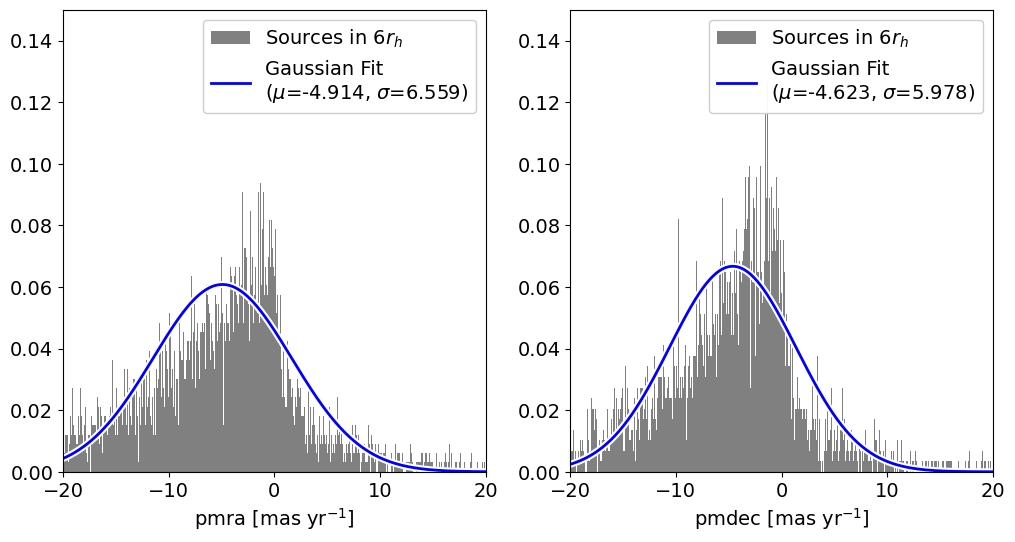

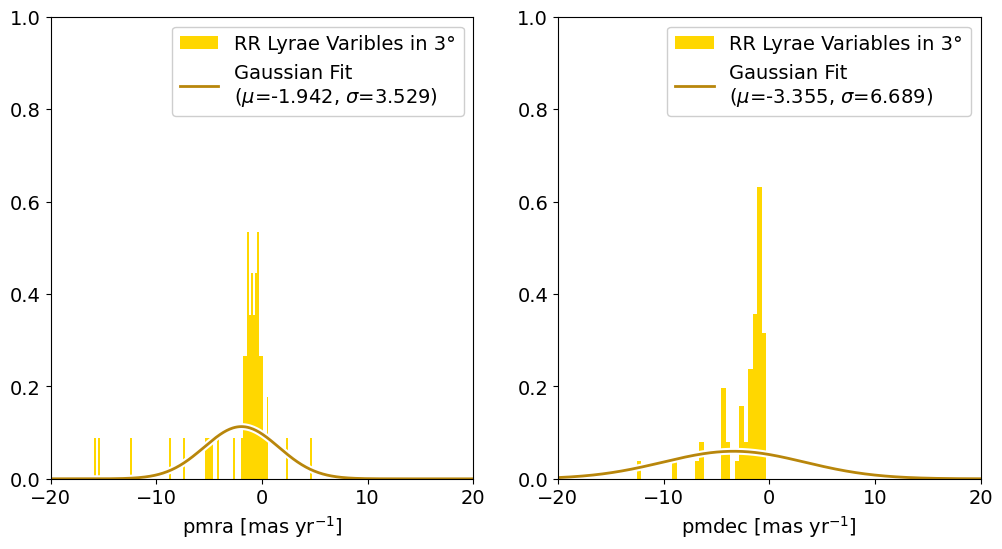

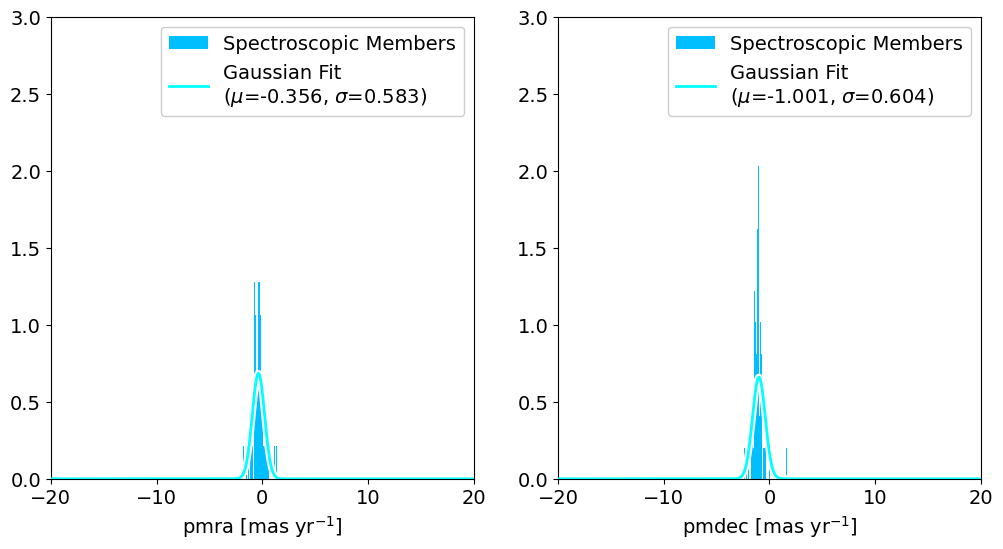

In [24]:
## Histograms

# Sources in 6*r_h

pm1, (pmra1, pmdec1) = plt.subplots(1, 2, figsize=(12,6))

pmra1.set_xlim(-20,20)
pmra1.set_ylim(0,0.15)
pmra1.tick_params(labelsize=14)
pmra1.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
pmra1.hist(data_6rh['pmra'], bins=len(data_6rh), density=True, label=r'Sources in 6$r_h$', color='grey')
pmra1.plot(x, p_ra, c='white', linewidth=5)
pmra1.plot(x, p_ra, c='blue', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_ra) + ', $\sigma$=' + '{:.3f}'.format(std_ra) + ')')
pmra1.legend(loc=1, fontsize=14, framealpha=0.95)

pmdec1.set_xlim(-20,20)
pmdec1.set_ylim(0,0.15)
pmdec1.tick_params(labelsize=14)
pmdec1.set_xlabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
pmdec1.hist(data_6rh['pmdec'], bins=len(data_6rh), density=True, label=r'Sources in 6$r_h$', color='grey')
pmdec1.plot(x, p_dec, c='white', linewidth=5)
pmdec1.plot(x, p_dec, c='blue', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_dec) + ', $\sigma$=' + '{:.3f}'.format(std_dec) + ')')
pmdec1.legend(loc=1, fontsize=14, framealpha=0.95)

plt.savefig('Plot/BootesI/BootesI_pm_sources.png', bbox_inches='tight', pad_inches=0)
plt.show()


# RR Lyrae in 3°

pm1, (pmra1, pmdec1) = plt.subplots(1, 2, figsize=(12,6))

pmra1.set_xlim(-20,20)
pmra1.set_ylim(0,1)
pmra1.tick_params(labelsize=14)
pmra1.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
pmra1.hist(rr['pmra'], bins=len(rr)+50, density=True, label=r'RR Lyrae Varibles in 3°', color='gold')
pmra1.plot(x_rr, p_rr_ra, c='white', linewidth=5)
pmra1.plot(x_rr, p_rr_ra, c='darkgoldenrod', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_rr_ra) + ', $\sigma$=' + '{:.3f}'.format(std_rr_ra) + ')')
pmra1.legend(loc=1, fontsize=14, framealpha=0.95)

pmdec1.set_xlim(-20,20)
pmdec1.set_ylim(0,1)
pmdec1.tick_params(labelsize=14)
pmdec1.set_xlabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
pmdec1.hist(rr['pmdec'], bins=len(rr)+50, density=True, label=r'RR Lyrae Variables in 3°', color='gold')
pmdec1.plot(x_rr, p_rr_dec, c='white', linewidth=5)
pmdec1.plot(x_rr, p_rr_dec, c='darkgoldenrod', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_rr_dec) + ', $\sigma$=' + '{:.3f}'.format(std_rr_dec) + ')')
pmdec1.legend(loc=1, fontsize=14, framealpha=0.95)

plt.savefig('Plot/BootesI/BootesI_pm_rr.png', bbox_inches='tight', pad_inches=0)
plt.show()


# With Spectroscopic Members

pm2, (pmra2, pmdec2) = plt.subplots(1, 2, figsize=(12,6))

pmra2.set_xlim(-20,20)
pmra2.set_ylim(0,3)
pmra2.tick_params(labelsize=14)
pmra2.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
pmra2.hist(memb['pmra'], bins=len(memb), density=True, label='Spectroscopic Members', color='deepskyblue', zorder=0)
pmra2.plot(x_memb, p_memb_ra, c='white', linewidth=5)
pmra2.plot(x_memb, p_memb_ra, c='cyan', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_memb_ra) + ', $\sigma$=' + '{:.3f}'.format(std_memb_ra) + ')', zorder=3)
pmra2.legend(loc=1, fontsize=14, framealpha=0.95)

pmdec2.set_xlim(-20,20)
pmdec2.set_ylim(0,3)
pmdec2.tick_params(labelsize=14)
pmdec2.set_xlabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
pmdec2.hist(memb['pmdec'], bins=len(memb), density=True, label='Spectroscopic Members', color='deepskyblue', zorder=0)
pmdec2.plot(x_memb, p_memb_dec, c='white', linewidth=5)
pmdec2.plot(x_memb, p_memb_dec, c='cyan', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_memb_dec) + ', $\sigma$=' + '{:.3f}'.format(std_memb_dec) + ')', zorder=3)
pmdec2.legend(loc=1, fontsize=14, framealpha=0.95)

plt.savefig('Plot/BootesI/BootesI_pm_memb.png', bbox_inches='tight', pad_inches=0)
plt.show()

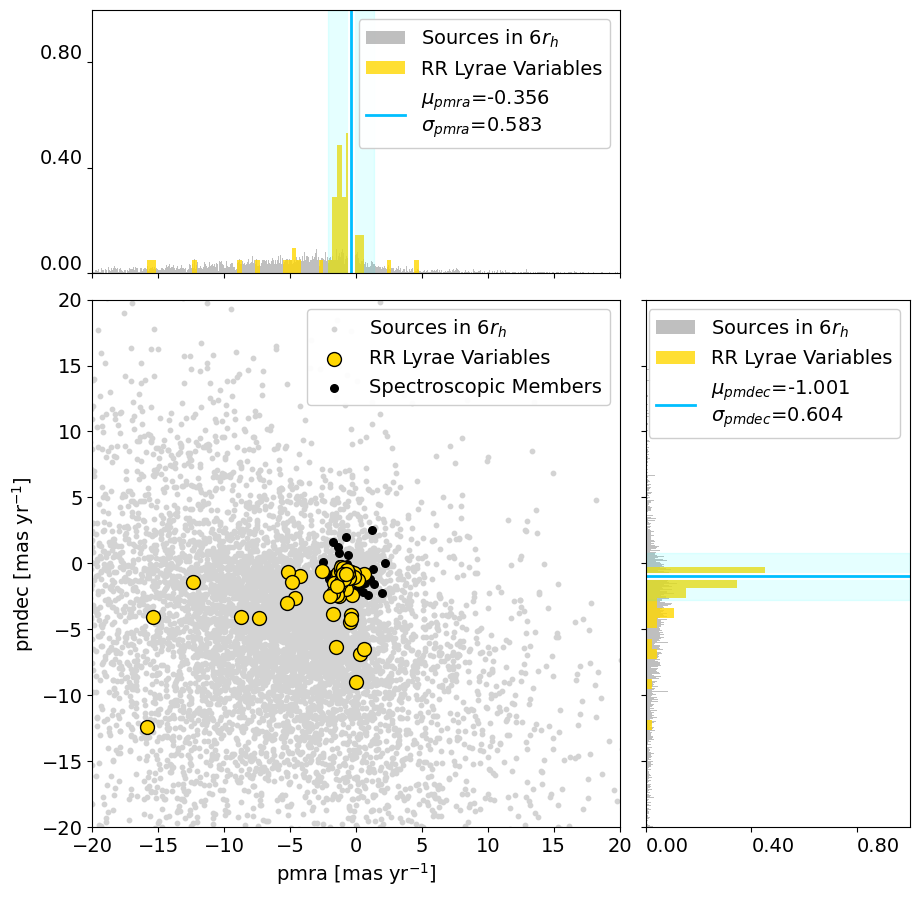

In [25]:
## PROPER MOTIONS

pm3 = plt.figure(layout='tight', figsize=(11,11))
ax3 = pm3.add_subplot()

ax3.set_aspect('equal')

ax3_histx = ax3.inset_axes([0, 1.05, 1, 0.5], sharex=ax3)
ax3_histy = ax3.inset_axes([1.05, 0, 0.5, 1], sharey=ax3)

scatter_hist(data_6rh['pmra'], data_6rh['pmdec'], rr['pmra'], rr['pmdec'], ax3, ax3_histx, ax3_histy, center_mymemb, err_mymemb)

ax3.scatter(memb['pmra'], memb['pmdec'], s=30, color='black', edgecolor='k', label='Spectroscopic Members')

ax3.legend(loc=1, fontsize=14, framealpha=0.95)

plt.setp(ax3_histy.get_xticklabels(), ha='left')
plt.setp(ax3_histx.get_yticklabels(), va='bottom')

plt.savefig('Plot/BootesI/BootesI_paper04.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

### Sources within 3$\sigma$ of mean proper motions (w.r.t. Spectroscopic Members)

In [26]:
## Sources in 3°

mask4 = (data['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (data['pmra'] >= mu_memb_ra - 3*std_memb_ra)

data_final = data[mask4]

mask4 = (data_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (data_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

data_final = data_final[mask4]

print('Sources within 3sigma of mean proper motions in 3°: ' + str(len(data_final)))


## Sources in 6*r_h

mask4 = (data_6rh['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (data_6rh['pmra'] >= mu_memb_ra - 3*std_memb_ra)

data_6rh_final = data_6rh[mask4]

mask4 = (data_6rh_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (data_6rh_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

data_6rh_final = data_6rh_final[mask4]

print('Sources within 3sigma of mean proper motions in 6r_h: ' + str(len(data_6rh_final)))


## RR Lyrae in 3°

mask5 = (rr['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (rr['pmra'] >= mu_memb_ra - 3*std_memb_ra)

rr_final = rr[mask5]

mask5 = (rr_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (rr_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

rr_final = rr_final[mask5]

print('RR Lyrae within 3sigma of mean proper motions in 3°: ' + str(len(rr_final)))


## RR Lyrae in 6*r_h

mask6 = (rr_6rh['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (rr_6rh['pmra'] >= mu_memb_ra - 3*std_memb_ra)

rr_6rh_final = rr_6rh[mask6]

mask6 = (rr_6rh_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (rr_6rh_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

rr_6rh_final = rr_6rh_final[mask6]

print('RR Lyrae within 3sigma of mean proper motions in 6r_h: ' + str(len(rr_6rh_final)))


## RR Lyrae Classified in 3°

mask7 = (add_class_rr['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (add_class_rr['pmra'] >= mu_memb_ra - 3*std_memb_ra)

add_class_rr_final = add_class_rr[mask7]

mask7 = (add_class_rr_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (add_class_rr_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

add_class_rr_final = add_class_rr_final[mask7]

print('Classified RR Lyrae within 3sigma of mean proper motions in 3°: ' + str(len(add_class_rr_final)))

Sources within 3sigma of mean proper motions in 3°: 5737
Sources within 3sigma of mean proper motions in 6r_h: 860
RR Lyrae within 3sigma of mean proper motions in 3°: 39
RR Lyrae within 3sigma of mean proper motions in 6r_h: 15
Classified RR Lyrae within 3sigma of mean proper motions in 3°: 2


In [27]:
## Sgr Stream cut in PM

print('Sgr Stream RRLy: ' + str(len(data_sgr)))

mask7a = (data_sgr['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (data_sgr['pmra'] >= mu_memb_ra - 3*std_memb_ra)

data_sgr_pmcut = data_sgr[mask7a]

mask7a = (data_sgr_pmcut['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (data_sgr_pmcut['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

data_sgr_pmcut = data_sgr_pmcut[mask7a]

print('Sgr Stream RRLy within 3sigma of mean proper motions in 3°: ' + str(len(data_sgr_pmcut)))

Sgr Stream RRLy: 14
Sgr Stream RRLy within 3sigma of mean proper motions in 3°: 14


### Period-Wesenheit-Metallicity Relation

In [28]:
w_mag_final = wesen(rr_final['int_average_g'], rr_final['phot_bp_mean_mag'], rr_final['phot_rp_mean_mag'])
w_mag_error_final = wesen_err(rr_final['int_average_g_error'], rr_final['phot_bp_mean_mag_error'], rr_final['phot_rp_mean_mag_error'])
w_mag_tau = wesen(tau_rr['int_average_g'], tau_rr['phot_bp_mean_mag'], tau_rr['phot_rp_mean_mag'])
w_mag_memb_rr = wesen(memb_rr['int_average_g'], memb_rr['phot_bp_mean_mag'], memb_rr['phot_rp_mean_mag'])


## Garofalo et al. 2022: intrinsic dispersion of 0.09 ± 0.01 mag

w_sigma = 0.09


## Period

period_final = np.log10(rr_final['pf'])
period_final[np.isnan(period_final)] = np.log10(rr_final['p1_o'][np.isnan(period_final)]) + 0.127


## Info. from Vivas et al. 2020

# Distance Module

mu0 = float(- 5 + 5 * np.log10(vivas['distance'] * 1000.0))

print('Distance Module: ' + str(mu0))


## Iron Abundance

fe = float(vivas['fe_h'])
fe_err = 0.43

print('Iron Abundance: ' + str(fe))


## General Wesenheit Relation

pw_line_final = pw(period_final, fe, mu0)


## Generic only for plot

t = np.linspace(-0.5, 0, 100)
pw_generic = pw(t, fe, mu0)


## RR Lyrae in 3sigma of PW

rr_pw_final = rr_final.copy()
rr_pw_final.insert(len(rr_pw_final.columns), 'w_mag', w_mag_final)
rr_pw_final.insert(len(rr_pw_final.columns), 'w_period', period_final)
rr_pw_final.insert(len(rr_pw_final.columns), 'pw_line', pw_line_final)

mask_pw_final = ((w_mag_final <= pw_line_final + 3*w_sigma) & (w_mag_final >= pw_line_final - 3*w_sigma) |
           (w_mag_final + w_mag_error_final <= pw_line_final + 3*w_sigma) & (w_mag_final + w_mag_error_final >= pw_line_final - 3*w_sigma) |
           (w_mag_final - w_mag_error_final <= pw_line_final + 3*w_sigma) & (w_mag_final - w_mag_error_final >= pw_line_final - 3*w_sigma))

rr_pw_final = rr_pw_final[mask_pw_final]

print('RR Lyrae within 3sigma of Wesenheit Relation: ' + str(len(rr_pw_final)))

Distance Module: 19.097719677709343
Iron Abundance: -2.59
RR Lyrae within 3sigma of Wesenheit Relation: 18


In [29]:
## Sgr Stream RR Lyrae in 3sigma of PWZ

w_mag_sgr = wesen(data_sgr['int_average_g'], data_sgr['phot_bp_mean_mag'], data_sgr['phot_rp_mean_mag'])
w_mag_sgr_error = wesen_err(data_sgr['int_average_g_error'], data_sgr['phot_bp_mean_mag_error'], data_sgr['phot_rp_mean_mag_error'])


# Period for Sagittarius Stream

period_sgr = np.log10(data_sgr['pf'])
period_sgr[np.isnan(period_sgr)] = np.log10(data_sgr['p1_o'][np.isnan(period_sgr)]) + 0.127


# General Wesenheit Relation

pw_line_sgr = pw(period_sgr, fe, mu0)


# 3sigma of PWZ

sgr_pw = data_sgr.copy()
sgr_pw.insert(len(sgr_pw.columns), 'w_mag', w_mag_sgr)
sgr_pw.insert(len(sgr_pw.columns), 'w_period', period_sgr)
sgr_pw.insert(len(sgr_pw.columns), 'pw_line', pw_line_sgr)

mask_pw_sgr = ((w_mag_sgr <= pw_line_sgr + 3*w_sigma) & (w_mag_sgr >= pw_line_sgr - 3*w_sigma) |
           (w_mag_sgr + w_mag_sgr_error <= pw_line_sgr + 3*w_sigma) & (w_mag_sgr + w_mag_sgr_error >= pw_line_sgr - 3*w_sigma) |
           (w_mag_sgr - w_mag_sgr_error <= pw_line_sgr + 3*w_sigma) & (w_mag_sgr - w_mag_sgr_error >= pw_line_sgr - 3*w_sigma))

sgr_pw = sgr_pw[mask_pw_sgr]

print('Sgr Stream RR Lyrae within 3sigma of Wesenheit Relation: ' + str(len(sgr_pw)))


print(sgr_pw['source_id'])

print(sgr_pw['FeH'])

#print(sgr_pw['e_FeH'])


# 3sigma of [Fe/H]

mask_fe = ((sgr_pw['FeH'] <= fe + 1*fe_err) & (sgr_pw['FeH'] >= fe - 1*fe_err) |
           (sgr_pw['FeH'] + sgr_pw['e_FeH'] <= fe + 1*fe_err) & (sgr_pw['FeH'] + sgr_pw['e_FeH'] >= fe - 1*fe_err) |
          (sgr_pw['FeH'] - sgr_pw['e_FeH'] <= fe + 1*fe_err) & (sgr_pw['FeH'] - sgr_pw['e_FeH'] >= fe - 1*fe_err))
           
print('Sgr Stream RR Lyrae within [Fe/H]: ' + str(len(sgr_pw[mask_fe])))


#sgr_pw.to_csv('Output/BootesI/BootesI_sgr_pm+pwz.csv', index=False)

Sgr Stream RR Lyrae within 3sigma of Wesenheit Relation: 5
0     1243152071642576896
5     1230612927506112000
6     1230741020611316224
8     1231507655093621632
12    3728687334175665920
Name: source_id, dtype: int64
0    -1.96
5    -1.79
6    -2.16
8    -2.52
12   -1.75
Name: FeH, dtype: float64
Sgr Stream RR Lyrae within [Fe/H]: 5


In [30]:
## Period of the two RRLs from vari_classifier

w_mag_add = wesen(add_class_rr['phot_g_mean_mag'], add_class_rr['phot_bp_mean_mag'], add_class_rr['phot_rp_mean_mag'])
w_mag_add_error = wesen_err(add_class_rr['phot_g_mean_mag_error'], add_class_rr['phot_bp_mean_mag_error'], add_class_rr['phot_rp_mean_mag_error'])


# Period

period_add = np.log10([0.376, 0.30236]) #0.31917, 0.30236 in PS1 (Tau 2024)

# Pulsation Periods retrieved from:
# 1230713292302089728 : Light curve re-analyzed and recalculated; 
#   since Tau et al. (2024) listed both PS1 and ZTF data, we verified to ensure the correct value was used
# 1230819704412148224 : taken from Tau 2024, PS1


# General Wesenheit Relation

pw_line_add = pw(period_add, fe, mu0)


# 3sigma of PWZ

add_class_rr.insert(len(add_class_rr.columns), 'w_mag', w_mag_add)
add_class_rr.insert(len(add_class_rr.columns), 'w_period', period_add)
add_class_rr.insert(len(add_class_rr.columns), 'pw_line', pw_line_add)

mask_pw_add = ((w_mag_add <= pw_line_add + 3*w_sigma) & (w_mag_add >= pw_line_add - 3*w_sigma) |
           (w_mag_add + w_mag_add_error <= pw_line_add + 3*w_sigma) & (w_mag_add + w_mag_add_error >= pw_line_add - 3*w_sigma) |
           (w_mag_add - w_mag_add_error <= pw_line_add + 3*w_sigma) & (w_mag_add - w_mag_add_error >= pw_line_add - 3*w_sigma))

add_class_rr = add_class_rr[mask_pw_add]

print('Classifier RR Lyrae within 3sigma of Wesenheit Relation: ' + str(len(add_class_rr)))


Classifier RR Lyrae within 3sigma of Wesenheit Relation: 2


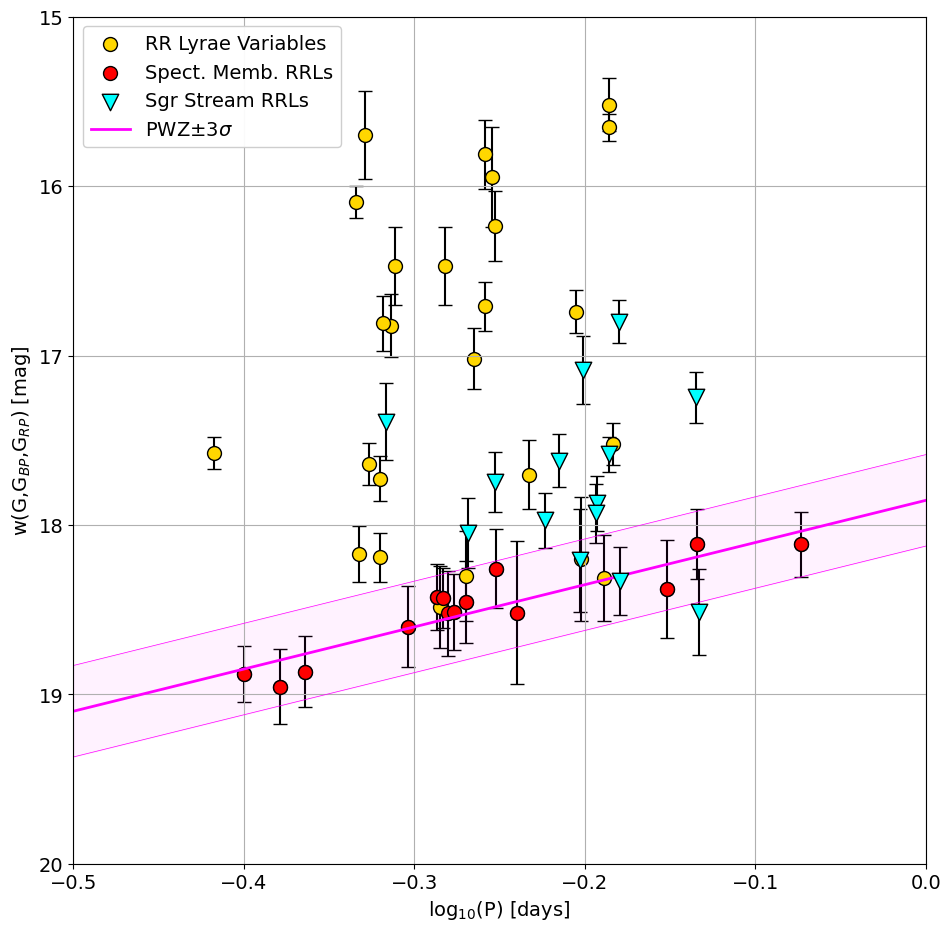

In [31]:
## PWZ

plt.figure(figsize=(11,11))
plt.xlim(-0.5,0)
plt.ylim(20,15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r'log$_{10}$(P) [days]', fontsize=14)
plt.ylabel(r'w(G,G$_{BP}$,G$_{RP}$) [mag]', fontsize=14)


## All RR Lyrae

plt.scatter(np.log10(rr_final['pf']), w_mag_final, c='gold', edgecolor='k', marker='o', s=100, label='RR Lyrae Variables', zorder=1)
plt.scatter(np.log10(rr_final['p1_o'])+0.127, w_mag_final, c='gold', edgecolor='k', marker='o', s=100, zorder=1) # Fundamentalisation
plt.errorbar(np.log10(rr_final['pf']), w_mag_final, yerr=w_mag_error_final, fmt='o', capsize=5, color='k', zorder=0)
plt.errorbar(np.log10(rr_final['p1_o'])+0.127, w_mag_final, yerr=w_mag_error_final, fmt='o', capsize=5, color='k', zorder=0)

plt.scatter(np.log10(period_add)+0.127, w_mag_add, s=140, marker='o', facecolors='gold', edgecolor='blue', linewidth=3, zorder=3) # Fundamentalisation
plt.errorbar(np.log10(period_add)+0.127, w_mag_add, yerr=w_mag_add_error, fmt='o', capsize=5, color='k', zorder=2)

plt.scatter(np.log10(memb_rr['pf']), w_mag_memb_rr, color='red', edgecolor='k', marker='o', s=100, label='Spect. Memb. RRLs', zorder=2)
plt.scatter(np.log10(memb_rr['p1_o'])+0.127, w_mag_memb_rr, color='red', edgecolor='k', marker='o', s=100, zorder=2)

plt.scatter(np.log10(data_sgr['pf']), w_mag_sgr, c='cyan', edgecolor='k', marker='v', s=140, label='Sgr Stream RRLs', zorder=3)
plt.scatter(np.log10(data_sgr['p1_o'])+0.127, w_mag_sgr, c='cyan', edgecolor='k', marker='v', s=140, zorder=3) # Fundamentalisation
plt.errorbar(np.log10(data_sgr['pf']), w_mag_sgr, yerr=w_mag_sgr_error, fmt='v', capsize=5, color='k', zorder=0)
plt.errorbar(np.log10(data_sgr['p1_o'])+0.127, w_mag_sgr, yerr=w_mag_sgr_error, fmt='v', capsize=5, color='k', zorder=0)


## Intrinsic dispersion

plt.plot(t, pw_generic, c='magenta', linewidth=2, label=r'PWZ$\pm 3 \sigma$', linestyle = 'solid')
plt.plot(t, pw_generic + 3*w_sigma, c='magenta', linewidth=0.5, linestyle = 'solid')
plt.plot(t, pw_generic - 3*w_sigma, c='magenta', linewidth=0.5, linestyle = 'solid')
plt.fill_between(t, pw_generic + 3*w_sigma, pw_generic - 3*w_sigma, alpha=0.05, color='magenta', zorder=0)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/BootesI/BootesI_paper05.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

### Color-Magnitude Diagram

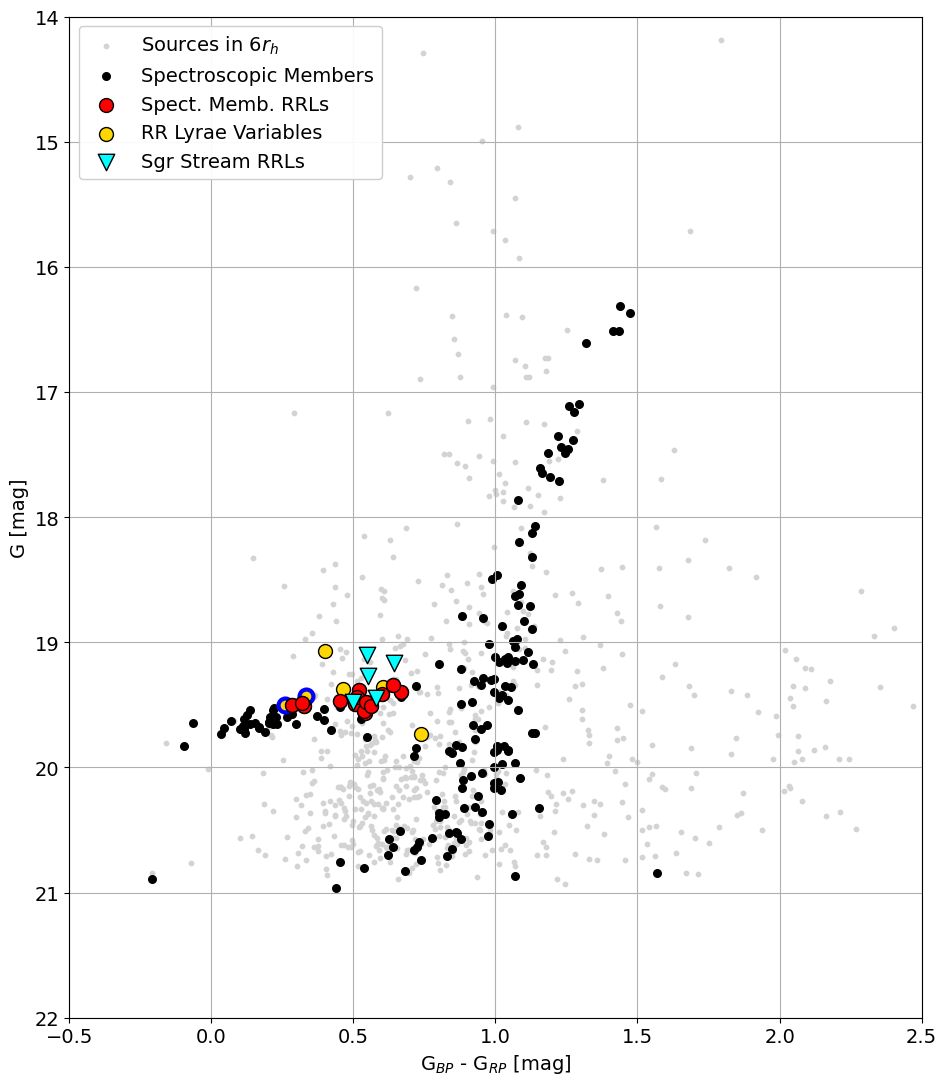

In [32]:
## CMD

plt.figure(figsize=(11,13))
plt.xlim(-0.5,2.5)
plt.ylim(22,14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r'G$_{BP}$ - G$_{RP}$ [mag]', fontsize=14)
plt.ylabel('G [mag]', fontsize=14)

plt.scatter(data_6rh_final['phot_bp_mean_mag'] - data_6rh_final['phot_rp_mean_mag'], data_6rh_final['phot_g_mean_mag'], s=10, c='lightgrey', marker='o', label=r'Sources in 6$r_h$', zorder=0)
plt.scatter(memb['phot_bp_mean_mag'] - memb['phot_rp_mean_mag'], memb['phot_g_mean_mag'], s=30, marker='o', c='k', edgecolor='k', label='Spectroscopic Members', zorder=1)
plt.scatter(memb_rr['phot_bp_mean_mag'] - memb_rr['phot_rp_mean_mag'], memb_rr['int_average_g'], s=100, marker='o', color='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=3)
plt.scatter(rr_pw_final['phot_bp_mean_mag'] - rr_pw_final['phot_rp_mean_mag'], rr_pw_final['int_average_g'], s=100, marker='o', edgecolor='k', color='gold', label=r'RR Lyrae Variables', zorder=2)
plt.scatter(add_class_rr['phot_bp_mean_mag'] - add_class_rr['phot_rp_mean_mag'], add_class_rr['phot_g_mean_mag'], s=100, marker='o', facecolors='gold', edgecolor='blue', linewidth=3, zorder=1)
plt.scatter(sgr_pw['phot_bp_mean_mag'] - sgr_pw['phot_rp_mean_mag'], sgr_pw['int_average_g'], s=140, marker='v', edgecolor='k', color='cyan', label='Sgr Stream RRLs', zorder=4)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/BootesI/BootesI_paper06.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

### Final Map

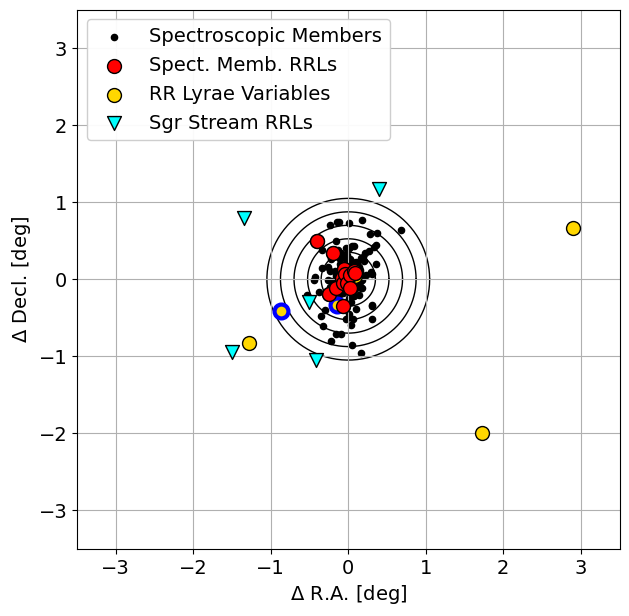

In [33]:
## Final map

t = np.linspace(0, 2*np.pi, 100)

plt.figure(figsize=(7,7))
plt.xlim(-3.5,3.5)
plt.ylim(-3.5,3.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(memb['ra'] - center[0], memb['dec'] - center[1], s=20, marker='o', c='black', edgecolor='k', label='Spectroscopic Members', zorder=1)
plt.scatter(memb_rr['ra'] - center[0], memb_rr['dec'] - center[1], s=100, marker='o', c='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=3)
plt.scatter(rr_pw_final['ra']- center[0], rr_pw_final['dec']- center[1], s=100, marker='o', c='gold', edgecolor='k', label='RR Lyrae Variables', zorder=2)
plt.scatter(add_class_rr['ra'] - center[0], add_class_rr['dec'] - center[1], s=100, marker='o', facecolors='gold', edgecolor='blue', linewidth=3, zorder=2)
plt.scatter(sgr_pw['ra'] - center[0], sgr_pw['dec'] - center[1], s=100, marker='v', color='cyan', edgecolor='k', label='Sgr Stream RRLs', zorder=3)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*4*np.cos(t),r_half*4*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*5*np.cos(t),r_half*5*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*6*np.cos(t),r_half*6*np.sin(t),c='k', linewidth=1, zorder=0)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)

plt.savefig('Plot/BootesI/BootesI_paper07.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

## File saving

In [34]:
# RR Lyrae in 3° after PM cut
#rr_final.to_csv('Output/BootesI/BootesI_rr_pm.csv', index=False)

# RR Lyrae in 3° after PM and PWZ cut
#rr_pw_final.to_csv('Output/BootesI/BootesI_rr_pm+pwz.csv', index=False)

# Final 25 RRLs in Bootes I
final = pd.concat([rr_pw_final, add_class_rr, sgr_pw])
print('Final member RR Lyrae: ' + str(len(final)))
final.to_csv('Output/BootesI/BootesI_rr_final.csv', index=False)

Final member RR Lyrae: 25


## Conclusions
- After Proper Motion, PWZ, and Metallicity selections, we found 25 RRLs: 18 in vari_rrlyrae + 2 in vari_classifier + 5 from Sgr Stream
- All the 14 Spectroscopic RRL members pass the PWZ selection
- For the 2 RRLs from vari_classifier, we extracted the periods from literature/lightcurves to compute Wesenheit magnitude
- Tau 2024 do not consider one "our" RRL: source_id = 1230519198435520128
- Tau 2024 considered a source which does not have a Gaia DR3 source_id, it is likely a non-variable source (we crossmatched it on TOPCAT): source_id = 3727814631180569088